# **EDA**

In [1]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re


DATASET_PATH = "shimmer-raw-dataset-dehydration"

def explore(path, indent=""):
    entries = sorted(os.listdir(path))
    subdirs = [e for e in entries if os.path.isdir(os.path.join(path, e))]
    csvs = [e for e in entries if e.lower().endswith('.csv')]

    print(f"{indent}{os.path.basename(path)}/  -> {len(subdirs)} folder, {len(csvs)} csv")

    if csvs and not subdirs:
        # sudah level paling dalam, tampilkan contoh nama file
        print(f"{indent}   contoh: {csvs[:3]}")
        return

    for d in subdirs:
        explore(os.path.join(path, d), indent + "  ")

explore(DATASET_PATH)


shimmer-raw-dataset-dehydration/  -> 11 folder, 0 csv
  S1/  -> 2 folder, 0 csv
    fasting/  -> 0 folder, 24 csv
       contoh: ['20210408100028Apr8_10_00_fasting.csv', '20210413094911Apr13_09_49_fasting.csv', '20210413151934Apr13_15_19_fasting.csv']
    nonfasting/  -> 0 folder, 22 csv
       contoh: ['20210404095727Apr4_09_10_notfasting.csv', '20210404121144Apr4_12_11_notfasting.csv', '20210407085013Apr7_08_48_notfasting.csv']
  S10/  -> 2 folder, 0 csv
    fasting/  -> 0 folder, 0 csv
    nonfasting/  -> 0 folder, 1 csv
       contoh: ['20211208125944nonfasting_S10.csv']
  S11/  -> 2 folder, 0 csv
    fasting/  -> 0 folder, 0 csv
    nonfasting/  -> 0 folder, 1 csv
       contoh: ['20211210101008nonfasting_S11.csv']
  S2/  -> 2 folder, 0 csv
    fasting/  -> 0 folder, 5 csv
       contoh: ['20211007164123oct07_04_41_fasting.csv', '20211011115220oct11_11_52_fasting.csv', '20211014123108oct14_12_31_fasting.csv']
    nonfasting/  -> 0 folder, 42 csv
       contoh: ['20211007222457oct0

In [2]:
csv_files = [
    f for f in Path(DATASET_PATH).rglob("*.csv")
    if 'fastingtime' not in f.name.lower()
    and f.parent.name.lower() in ('fasting', 'nonfasting')
]

def extract_meta(f: Path):
    session = f.parent.name.lower()
    subject_id = f.parent.parent.name
    return subject_id, session

meta_df = pd.DataFrame([
    {"file": f.name, "path": str(f), **dict(zip(["subject_id","session_type"], extract_meta(f)))}
    for f in csv_files
])
display(pd.crosstab(meta_df['subject_id'], meta_df['session_type']))

session_type,fasting,nonfasting
subject_id,,
S1,23,22
S10,0,1
S11,0,1
S2,4,42
S3,4,4
S4,8,4
S5,4,1
S6,2,0
S7,0,1


**Total baris per subjek per sesi**

In [3]:
summary = []
for r in meta_df.itertuples():
    n_rows = sum(1 for _ in open(r.path)) - 1
    summary.append({"subject_id": r.subject_id, "session_type": r.session_type, "n_rows": n_rows})

pivot = pd.DataFrame(summary).pivot_table(
    index='subject_id', columns='session_type', values='n_rows', aggfunc='sum', fill_value=0
)
pivot

session_type,fasting,nonfasting
subject_id,,
S1,1917974,3391555
S10,0,64719
S11,0,96366
S2,154700,1648677
S3,249872,280832
S4,868862,857324
S5,65307,174583
S6,65500,0
S7,0,72411


**Pengecekan folder yang ada FastingTime.csv**

Tujuan: sumber ground truth label yang nanti dipakai buat nentuin kondisi Dehydration

In [4]:
fasting_time_files = list(set(Path(DATASET_PATH).rglob("*asting*imes.csv")))
coverage = {f.parent.parent.name: f for f in fasting_time_files}

subjects_fasting = meta_df[meta_df.session_type == 'fasting']['subject_id'].unique()
for s in sorted(subjects_fasting):
    print(s, "-> ada fastingTimes.csv" if s in coverage else "-> TIDAK ADA")

S1 -> ada fastingTimes.csv
S2 -> ada fastingTimes.csv
S3 -> ada fastingTimes.csv
S4 -> ada fastingTimes.csv
S5 -> ada fastingTimes.csv
S6 -> ada fastingTimes.csv


In [5]:
for s, f in coverage.items():
    print(f"--- {s} ({f.name}) ---")
    display(pd.read_csv(f))

--- S4 (fastingTimes.csv) ---


,RecordingTime,FastingTime
0,20211203103200,20211202230000
1,20211204080716,20211203230000
2,20211204093506,20211203230000
3,20211205041234,20211204210000
4,20211209064440,20211209000000
5,20211211084723,20211211003000
6,20211211094648,20211211003000
7,20211215134443,20211215113000


--- S1 (fastingTimes.csv) ---


,RecordingTime,FastingTime
0,20210408100028,20210408035000
1,20210413094911,20210413035000
2,20210413151934,20210413035000
3,20210414154151,20210414003000
4,20210415081723,20210415035000
5,20210415165621,20210415035000
6,20210417163344,20210417035000
7,20210418120309,20210418035000
8,20210419082504,20210419035000
9,20210420094756,20210420035000


--- S5 (fastingTimes.csv) ---


...

,RecordingTime,FastingTime
0,20211129134509,20211129020000
1,20211129160847,20211129020000
2,20211129162445,20211129020000
3,20211129164759,20211129020000


--- S2 (fastingTimes.csv) ---


,RecordingTime,FastingTime
0,20211007164123,20211007040000
1,20211011115220,20211011040000
2,20211014123108,20211014040000
3,20211014170751,20211014040000


--- S6 (fastingTimes.csv) ---


,RecordingTime,FastingTime
0,20211204100231,20211203230000
1,20211211100619,20211211000000


**Cek sampling rate & durasi real per subjek**

In [6]:
sample_path = meta_df.iloc[0]['path']

print("=== 5 baris mentah file (raw text) ===")
with open(sample_path) as f:
    for i in range(5):
        print(f"[{i}] {f.readline().strip()[:200]}")

print("\n=== Kolom hasil pd.read_csv default ===")
df_test = pd.read_csv(sample_path)
print(df_test.columns.tolist())

=== 5 baris mentah file (raw text) ===
[0] Shimmer_D1B2,Shimmer_D1B2,Shimmer_D1B2,Shimmer_D1B2,Shimmer_D1B2,Shimmer_D1B2,Shimmer_D1B2,Shimmer_D1B2,Shimmer_D1B2,Shimmer_D1B2,Shimmer_D1B2,Shimmer_D1B2,Shimmer_D1B2,Shimmer_D1B2,Shimmer_D1B2,Shimm
[1] PPG_A13,PPG_A13,Accel_LN_X,Accel_LN_X,Accel_LN_Y,Accel_LN_Y,Accel_LN_Z,Accel_LN_Z,Mag_Z,Mag_Z,Mag_X,Mag_X,System_Timestamp_Plot_Zeroed,Mag_Y,Mag_Y,Ext_Exp_A15,Ext_Exp_A15,Temperature_BMP280,Temperatur
[2] UNCAL,CAL,UNCAL,CAL,CAL,UNCAL,CAL,UNCAL,UNCAL,CAL,UNCAL,CAL,CAL,CAL,UNCAL,UNCAL,CAL,UNCAL,CAL,UNCAL,CAL,CAL,UNCAL,CAL,UNCAL,CAL,UNCAL,UNCAL,CAL,CAL,UNCAL,CAL,CAL,UNCAL,UNCAL,CAL,UNCAL,CAL
[3] no_units,mV,no_units,m/(s^2),m/(s^2),no_units,m/(s^2),no_units,no_units,local_flux,no_units,local_flux,ms,local_flux,no_units,no_units,mV,no_units,Degrees Celsius,no_units,kOhms,deg/s,no_units,no_unit
[4] 114,83.5164835164835,2110,8.70652173913043,1.55434782608696,1452,-3.55434782608696,2580,-422,0.632683658170914,138,0.754122938530734,40172.0886230469,

C:\Users\Raisa Shahira\AppData\Local\Temp\ipykernel_16252\1262963674.py:9: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37) have mixed types. Specify dtype option on import or set low_memory=False.
  df_test = pd.read_csv(sample_path)


['Shimmer_D1B2', 'Shimmer_D1B2.1', 'Shimmer_D1B2.2', 'Shimmer_D1B2.3', 'Shimmer_D1B2.4', 'Shimmer_D1B2.5', 'Shimmer_D1B2.6', 'Shimmer_D1B2.7', 'Shimmer_D1B2.8', 'Shimmer_D1B2.9', 'Shimmer_D1B2.10', 'Shimmer_D1B2.11', 'Shimmer_D1B2.12', 'Shimmer_D1B2.13', 'Shimmer_D1B2.14', 'Shimmer_D1B2.15', 'Shimmer_D1B2.16', 'Shimmer_D1B2.17', 'Shimmer_D1B2.18', 'Shimmer_D1B2.19', 'Shimmer_D1B2.20', 'Shimmer_D1B2.21', 'Shimmer_D1B2.22', 'Shimmer_D1B2.23', 'Shimmer_D1B2.24', 'Shimmer_D1B2.25', 'Shimmer_D1B2.26', 'Shimmer_D1B2.27', 'Shimmer_D1B2.28', 'Shimmer_D1B2.29', 'Shimmer_D1B2.30', 'Shimmer_D1B2.31', 'Shimmer_D1B2.32', 'Shimmer_D1B2.33', 'Shimmer_D1B2.34', 'Shimmer_D1B2.35', 'Shimmer_D1B2.36', 'Shimmer_D1B2.37']


In [7]:
def load_shimmer_csv(path):
    with open(path) as f:
        f.readline()  # baris 0: device id, skip
        signal = f.readline().strip().split(',')
        caluncal = f.readline().strip().split(',')
        f.readline()  # baris 3: units, skip

    raw_names = [f"{s}_{c}" for s, c in zip(signal, caluncal)]

    seen = {}
    colnames = []
    for name in raw_names:
        if name in seen:
            seen[name] += 1
            colnames.append(f"{name}_{seen[name]}")
        else:
            seen[name] = 0
            colnames.append(name)

    return pd.read_csv(path, skiprows=4, header=None, names=colnames, low_memory=False)

df = load_shimmer_csv(sample_path)
print(df.shape)
df.head()

(388976, 38)


,PPG_A13_UNCAL,PPG_A13_CAL,Accel_LN_X_UNCAL,Accel_LN_X_CAL,Accel_LN_Y_CAL,Accel_LN_Y_UNCAL,Accel_LN_Z_CAL,Accel_LN_Z_UNCAL,Mag_Z_UNCAL,Mag_Z_CAL,...,Gyro_X_CAL,Gyro_Y_CAL,Gyro_Y_UNCAL,GSR_Skin_Conductance_CAL,GSR_Skin_Conductance_CAL_1,GSR_Skin_Conductance_UNCAL,Battery_UNCAL,Battery_CAL,Pressure_BMP280_UNCAL,Pressure_BMP280_CAL
0,114,83.516484,2110,8.706522,1.554348,1452,-3.554348,2580,-422,0.632684,...,-1.389313,1.068702,91,0.073038,0.073038,847,2795,4095.238095,4924672,100.985468
1,114,83.516484,2108,8.695652,1.576087,1453,-3.489130,2574,-410,0.614693,...,0.351145,1.862595,-23,0.073038,0.073038,847,2800,4102.564103,4924928,100.982761
2,113,82.783883,2109,8.684783,1.565217,1454,-3.554348,2580,-416,0.623688,...,1.068702,2.076336,-70,0.073038,0.073038,847,2786,4082.051282,4925184,100.980055
3,114,83.516484,2108,8.706522,1.576087,1452,-3.586957,2583,-418,0.626687,...,0.106870,0.854962,-7,0.073038,0.073038,847,2801,4104.029304,4924672,100.985468
4,112,82.051282,2107,8.728261,1.586957,1450,-3.543478,2579,-409,0.613193,...,-1.068702,0.870229,70,0.073038,0.073038,847,2811,4118.681319,4924928,100.982761


In [8]:
duplicated = [n for n in colnames if n.endswith(('_1','_2','_3'))] if 'colnames' in dir() else []
print(df.columns.tolist())

['PPG_A13_UNCAL', 'PPG_A13_CAL', 'Accel_LN_X_UNCAL', 'Accel_LN_X_CAL', 'Accel_LN_Y_CAL', 'Accel_LN_Y_UNCAL', 'Accel_LN_Z_CAL', 'Accel_LN_Z_UNCAL', 'Mag_Z_UNCAL', 'Mag_Z_CAL', 'Mag_X_UNCAL', 'Mag_X_CAL', 'System_Timestamp_Plot_Zeroed_CAL', 'Mag_Y_CAL', 'Mag_Y_UNCAL', 'Ext_Exp_A15_UNCAL', 'Ext_Exp_A15_CAL', 'Temperature_BMP280_UNCAL', 'Temperature_BMP280_CAL', 'GSR_Skin_Resistance_UNCAL', 'GSR_Skin_Resistance_CAL', 'Gyro_Z_CAL', 'Gyro_Z_UNCAL', 'GSR_Range_CAL', 'GSR_Range_UNCAL', 'Timestamp_CAL', 'Timestamp_UNCAL', 'Gyro_X_UNCAL', 'Gyro_X_CAL', 'Gyro_Y_CAL', 'Gyro_Y_UNCAL', 'GSR_Skin_Conductance_CAL', 'GSR_Skin_Conductance_CAL_1', 'GSR_Skin_Conductance_UNCAL', 'Battery_UNCAL', 'Battery_CAL', 'Pressure_BMP280_UNCAL', 'Pressure_BMP280_CAL']


In [9]:
def load_shimmer_csv(path, return_units=False):
    with open(path) as f:
        f.readline()  # device id
        signal = f.readline().strip().split(',')
        caluncal = f.readline().strip().split(',')
        units = f.readline().strip().split(',')

    raw_names = [f"{s}_{c}" for s, c in zip(signal, caluncal)]
    seen, colnames = {}, []
    for name in raw_names:
        seen[name] = seen.get(name, -1) + 1
        colnames.append(name if seen[name] == 0 else f"{name}_{seen[name]}")

    df = pd.read_csv(path, skiprows=4, header=None, names=colnames, low_memory=False)
    return (df, dict(zip(colnames, units))) if return_units else df

df, units = load_shimmer_csv(sample_path, return_units=True)

print("--- Kandidat kolom timestamp ---")
for c in [x for x in df.columns if 'timestamp' in x.lower()]:
    print(f"{c} | unit: {units[c]} | awal: {df[c].head(2).tolist()} | akhir: {df[c].tail(2).tolist()}")

print("\n--- Kolom GSR ---")
for c in [x for x in df.columns if 'gsr' in x.lower()]:
    print(f"{c} | unit: {units[c]} | sample: {df[c].head(3).tolist()}")

--- Kandidat kolom timestamp ---
System_Timestamp_Plot_Zeroed_CAL | unit: ms | awal: [40172.0886230469, 40191.6198730469] | akhir: [7666363.49487305, 7666383.02612305]
Timestamp_CAL | unit: ms | awal: [200974.365234375, 200993.896484375] | akhir: [7827165.77148438, 7827185.30273438]
Timestamp_UNCAL | unit: Ticks | awal: [6585528, 6586168] | akhir: [4822328, 4822968]

--- Kolom GSR ---
GSR_Skin_Resistance_UNCAL | unit: no_units | sample: [847, 847, 847]
GSR_Skin_Resistance_CAL | unit: kOhms | sample: [13691.4893617021, 13691.4893617021, 13691.4893617021]
GSR_Range_CAL | unit: no_units | sample: [3, 3, 3]
GSR_Range_UNCAL | unit: no_units | sample: [3, 3, 3]
GSR_Skin_Conductance_CAL | unit: uS | sample: [0.073038073038073, 0.073038073038073, 0.073038073038073]
GSR_Skin_Conductance_CAL_1 | unit: microSiemens | sample: [0.073038073038073, 0.073038073038073, 0.073038073038073]
GSR_Skin_Conductance_UNCAL | unit: uS | sample: [847, 847, 847]


In [10]:
def get_duration_sr_fast(path):
    with open(path) as f:
        f.readline()
        signal = f.readline().strip().split(',')
        caluncal = f.readline().strip().split(',')
        f.readline()

    colnames = [f"{s}_{c}" for s, c in zip(signal, caluncal)]
    ts_idx = colnames.index('System_Timestamp_Plot_Zeroed_CAL')

    ts = pd.read_csv(path, skiprows=4, header=None, usecols=[ts_idx], names=['ts'])['ts']
    ts = pd.to_numeric(ts, errors='coerce').dropna()
    dur_sec = (ts.max() - ts.min()) / 1000
    sr = len(ts) / dur_sec if dur_sec else None
    return round(dur_sec/60, 1), round(sr, 1)

rows = []
for r in meta_df.itertuples():
    dur_min, sr = get_duration_sr_fast(r.path)
    rows.append({"subject_id": r.subject_id, "session_type": r.session_type, "duration_min": dur_min, "sampling_rate_hz": sr})

pd.DataFrame(rows).groupby(['subject_id','session_type']).agg(
    total_duration_min=('duration_min','sum'),
    avg_sampling_rate=('sampling_rate_hz','mean')
)

total_duration_min  avg_sampling_rate
subject_id session_type                                       
S1         fasting                    627.6          50.356522
           nonfasting               69386.8          44.018182
S10        nonfasting                  21.1          51.200000
S11        nonfasting                  31.4          51.100000
S2         fasting                     50.4          51.200000
           nonfasting                5515.8          47.678571
S3         fasting                     81.3          51.200000
           nonfasting                  91.4          51.200000
S4         fasting                    283.0          51.212500
           nonfasting                2335.4          38.575000
S5         fasting                     22.0          50.350000
           nonfasting                  56.8          51.200000
S6         fasting                     21.4          51.200000
S7         nonfasting                  23.6          51.200000
S8         nonfasting                  19.3          51.250000
S9         nonfasting                  21.3          51.200000

In [11]:
def extract_record_start(fname):
    match = re.match(r'(\d{14})', fname)
    return pd.to_datetime(match.group(1), format='%Y%m%d%H%M%S') if match else None

meta_df['record_start'] = meta_df['file'].apply(extract_record_start)
meta_df[['file', 'subject_id', 'session_type', 'record_start']].head(10)

,file,subject_id,session_type,record_start
0,20210408100028Apr8_10_00_fasting.csv,S1,fasting,2021-04-08 10:00:28
1,20210413094911Apr13_09_49_fasting.csv,S1,fasting,2021-04-13 09:49:11
2,20210413151934Apr13_15_19_fasting.csv,S1,fasting,2021-04-13 15:19:34
3,20210414154151Apr14_15_41_fasting.csv,S1,fasting,2021-04-14 15:41:51
4,20210415081723Apr15_08_17_fasting.csv,S1,fasting,2021-04-15 08:17:23
5,20210415165621April15_1656_fasting.csv,S1,fasting,2021-04-15 16:56:21
6,20210417163344April17_16_33_fasting.csv,S1,fasting,2021-04-17 16:33:44
7,20210418120309April18_12_02_fasting.csv,S1,fasting,2021-04-18 12:03:09
8,20210419082504April19_08_25_fasting.csv,S1,fasting,2021-04-19 08:25:04
9,20210420094756April20_09_47_fasting.csv,S1,fasting,2021-04-20 09:47:56


In [12]:
def get_duration_sr_robust(path):
    with open(path) as f:
        f.readline()
        signal = f.readline().strip().split(',')
        caluncal = f.readline().strip().split(',')
        f.readline()

    colnames = [f"{s}_{c}" for s, c in zip(signal, caluncal)]
    ts_idx = colnames.index('System_Timestamp_Plot_Zeroed_CAL')

    ts = pd.read_csv(path, skiprows=4, header=None, usecols=[ts_idx], names=['ts'])['ts']
    ts = pd.to_numeric(ts, errors='coerce').dropna()

    if len(ts) < 2:
        return None, None, 0, None

    diffs = ts.diff().dropna()
    median_diff = diffs.median()

    if pd.isna(median_diff) or median_diff <= 0:
        return None, None, 0, None

    n_gaps = (diffs > median_diff * 5).sum()
    gap_ratio = n_gaps / len(diffs)

    dur_sec_robust = median_diff * len(ts) / 1000
    sr_robust = 1000 / median_diff
    return round(dur_sec_robust/60, 1), round(sr_robust, 1), n_gaps, round(gap_ratio*100, 2)

rows = []
for r in meta_df.itertuples():
    dur_min, sr, n_gaps, gap_pct = get_duration_sr_robust(r.path)
    rows.append({"subject_id": r.subject_id, "session_type": r.session_type, "file": r.file,
                 "duration_min": dur_min, "sampling_rate_hz": sr, "gap_pct": gap_pct})

result_df = pd.DataFrame(rows)
display(result_df.groupby(['subject_id','session_type']).agg(
    total_duration_min=('duration_min','sum'),
    avg_sampling_rate=('sampling_rate_hz','mean')
))

print("\nFile bermasalah (durasi/sampling rate gagal dihitung):")
display(result_df[result_df['duration_min'].isna()])

print("\nFile dengan gap_pct tertinggi:")
result_df.sort_values('gap_pct', ascending=False).head(10)

total_duration_min  avg_sampling_rate
subject_id session_type                                       
S1         fasting                    624.4          51.200000
           nonfasting               14976.8          48.881818
S10        nonfasting                  21.1          51.200000
S11        nonfasting                  31.4          51.200000
S2         fasting                     50.4          51.200000
           nonfasting                 529.1          50.200000
S3         fasting                     81.3          51.200000
           nonfasting                  91.4          51.200000
S4         fasting                    282.7          51.200000
           nonfasting                 279.1          51.200000
S5         fasting                     21.1          51.200000
           nonfasting                  56.8          51.200000
S6         fasting                     21.4          51.200000
S7         nonfasting                  23.6          51.200000
S8         nonfasting                  19.3          51.200000
S9         nonfasting                  21.3          51.200000


File bermasalah (durasi/sampling rate gagal dihitung):


,subject_id,session_type,file,duration_min,sampling_rate_hz,gap_pct
64,S2,nonfasting,20211014211336oct14-afteriftar_2113.csv,NaN,NaN,NaN



File dengan gap_pct tertinggi:


,subject_id,session_type,file,duration_min,sampling_rate_hz,gap_pct
78,S2,nonfasting,20211022151633oct22_nonfast_1516.csv,32.1,51.2,29.39
110,S4,nonfasting,20211204154749nonfasting_S4.csv,29.7,51.2,27.12
43,S1,nonfasting,20210930071010Sep30_07_09_notfasting.csv,125.0,51.2,5.83
87,S2,nonfasting,20211030151006oct30_nonfast_1509.csv,10.0,10.2,2.15
25,S1,nonfasting,20210407085013Apr7_08_48_notfasting.csv,27.4,51.2,0.28
15,S1,fasting,20210424165256April24_16_52_fasting.csv,0.3,51.2,0.11
17,S1,fasting,20210425081128April25_08_11_fasting.csv,0.4,51.2,0.09
6,S1,fasting,20210417163344April17_16_33_fasting.csv,12.0,51.2,0.04
30,S1,nonfasting,20210825161636Aug25_15_16_notfasting.csv,6.7,51.2,0.04
11,S1,fasting,20210421155031April21_15_50_fasting.csv,0.9,51.2,0.04


cek file bermasalah di S2 nonfasting

In [13]:
bad_path = meta_df[meta_df.file == "20211014211336oct14-afteriftar_2113.csv"]['path'].values[0]

with open(bad_path) as f:
    device_row = f.readline().strip().split(',')
    signal_row = f.readline().strip().split(',')
    caluncal_row = f.readline().strip().split(',')
    units_row = f.readline().strip().split(',')

print("Jumlah kolom signal:", len(signal_row))
print("Jumlah kolom caluncal:", len(caluncal_row))
print("Jumlah kolom units:", len(units_row))

colnames_raw = list(zip(signal_row, caluncal_row))
for i, (s, c) in enumerate(colnames_raw):
    print(i, s, c)

colnames = [f"{s}_{c}" for s, c in colnames_raw]
target = 'System_Timestamp_Plot_Zeroed_CAL'

if target in colnames:
    print("KETEMU di index:", colnames.index(target))
else:
    print("TIDAK KETEMU. Kandidat mirip:")
    print([c for c in colnames if 'timestamp' in c.lower()])

if target in colnames:
    ts_idx = colnames.index(target)
    ts_raw = pd.read_csv(bad_path, skiprows=4, header=None, usecols=[ts_idx], names=['ts'])['ts']
    print("Jumlah baris:", len(ts_raw))
    print("Contoh nilai:", ts_raw.head(5).tolist())
    print("Jumlah valid numeric:", pd.to_numeric(ts_raw, errors='coerce').notna().sum())

with open(bad_path) as f:
    total_lines = sum(1 for _ in f)
print("Total baris file (termasuk 4 header):", total_lines)
print("Baris data:", total_lines - 4)

Jumlah kolom signal: 48
Jumlah kolom caluncal: 48
Jumlah kolom units: 48
0 Accel_LN_X CAL
1 Accel_LN_X UNCAL
2 Accel_LN_Y CAL
3 Accel_LN_Y UNCAL
4 Accel_LN_Z CAL
5 Accel_LN_Z UNCAL
6 GSR_Range CAL
7 GSR_Range UNCAL
8 Timestamp UNCAL
9 Timestamp CAL
10 GSR_Skin_Conductance CAL
11 GSR_Skin_Conductance CAL
12 GSR_Skin_Conductance UNCAL
13 Battery UNCAL
14 Battery CAL
15 Pressure_BMP280 UNCAL
16 Pressure_BMP280 CAL
17 PPG_A13 UNCAL
18 PPG_A13 CAL
19 Mag_Z CAL
20 Mag_Z UNCAL
21 Mag_X CAL
22 Mag_X UNCAL
23 System_Timestamp_Plot_Zeroed CAL
24 Mag_Y UNCAL
25 Mag_Y CAL
26 Ext_Exp_A15 UNCAL
27 Ext_Exp_A15 CAL
28 Temperature_BMP280 UNCAL
29 Temperature_BMP280 CAL
30 GSR_Skin_Resistance CAL
31 GSR_Skin_Resistance UNCAL
32 Gyro_Z UNCAL
33 Gyro_Z CAL
34 Gyro_X UNCAL
35 Gyro_X CAL
36 Gyro_Y UNCAL
37 Gyro_Y CAL
38 Ext_Exp_A6 UNCAL
39 Ext_Exp_A6 CAL
40 Ext_Exp_A7 UNCAL
41 Ext_Exp_A7 CAL
42 Accel_WR_Z CAL
43 Accel_WR_Z UNCAL
44 Accel_WR_Y UNCAL
45 Accel_WR_Y CAL
46 Accel_WR_X CAL
47 Accel_WR_X UNCAL
KET

In [14]:
ts_raw = pd.read_csv(bad_path, skiprows=4, header=None, usecols=[23], names=['ts'])['ts']
ts_raw = pd.to_numeric(ts_raw, errors='coerce').dropna()

diffs = ts_raw.diff().dropna()
print("Persentase diff == 0 (timestamp stuck):", round((diffs == 0).mean() * 100, 2), "%")
print("\nTop 5 nilai diff paling sering muncul:")
print(diffs.value_counts().head(5))

Persentase diff == 0 (timestamp stuck): 97.86 %

Top 5 nilai diff paling sering muncul:
ts
0.000000          46826
100000.000000       900
5000.000000          68
1000000.000000       54
2236.480713           1
Name: count, dtype: int64


In [15]:
def check_timestamp_quality(path, ts_col='System_Timestamp_Plot_Zeroed_CAL'):
    with open(path) as f:
        f.readline()
        signal = f.readline().strip().split(',')
        caluncal = f.readline().strip().split(',')
        f.readline()
    colnames = [f"{s}_{c}" for s, c in zip(signal, caluncal)]
    if ts_col not in colnames:
        return None
    ts_idx = colnames.index(ts_col)
    ts = pd.to_numeric(pd.read_csv(path, skiprows=4, header=None, usecols=[ts_idx], names=['ts'])['ts'], errors='coerce').dropna()
    if len(ts) < 2:
        return 100.0
    diffs = ts.diff().dropna()
    return round((diffs == 0).mean() * 100, 2)

quality_rows = []
for r in meta_df.itertuples():
    pct_stuck = check_timestamp_quality(r.path)
    quality_rows.append({"subject_id": r.subject_id, "session_type": r.session_type, "file": r.file, "pct_timestamp_stuck": pct_stuck})

quality_df = pd.DataFrame(quality_rows)
quality_df.sort_values('pct_timestamp_stuck', ascending=False).head(15)

,subject_id,session_type,file,pct_timestamp_stuck
64,S2,nonfasting,20211014211336oct14-afteriftar_2113.csv,97.86
43,S1,nonfasting,20210930071010Sep30_07_09_notfasting.csv,0.20
25,S1,nonfasting,20210407085013Apr7_08_48_notfasting.csv,0.02
93,S3,fasting,20211129134509November29_fasting.csv,0.00
91,S2,nonfasting,20211102190543nov02_nonfast_1905.csv,0.00
90,S2,nonfasting,20211031142349oct31_nonfast_1423.csv,0.00
89,S2,nonfasting,20211031093739oct31_nonfast_0937.csv,0.00
88,S2,nonfasting,20211030190515oct30_nonfast_1905.csv,0.00
87,S2,nonfasting,20211030151006oct30_nonfast_1509.csv,0.00
86,S2,nonfasting,20211030095347oct30_nonfast_0953.csv,0.00


OKK FILE ITU RUSAK HARUS DIEXCLUDE

In [16]:
EXCLUDED_FILES = ["20211014211336oct14-afteriftar_2113.csv"]

meta_df_clean = meta_df[~meta_df['file'].isin(EXCLUDED_FILES)].reset_index(drop=True) # mulai skrg pake ini

In [17]:
fasting_time_files = list(set(Path(DATASET_PATH).rglob("*asting*imes.csv")))

fasting_all = pd.concat([
    pd.read_csv(f).assign(subject_id=f.parent.parent.name, source_file=f.name)
    for f in fasting_time_files
], ignore_index=True)

fasting_all

,RecordingTime,FastingTime,subject_id,source_file
0,20211203103200,20211202230000,S4,fastingTimes.csv
1,20211204080716,20211203230000,S4,fastingTimes.csv
2,20211204093506,20211203230000,S4,fastingTimes.csv
3,20211205041234,20211204210000,S4,fastingTimes.csv
4,20211209064440,20211209000000,S4,fastingTimes.csv
5,20211211084723,20211211003000,S4,fastingTimes.csv
6,20211211094648,20211211003000,S4,fastingTimes.csv
7,20211215134443,20211215113000,S4,fastingTimes.csv
8,20210408100028,20210408035000,S1,fastingTimes.csv
9,20210413094911,20210413035000,S1,fastingTimes.csv


In [18]:
# hitung durasi puasa (jam) per baris fastingTimes
fasting_all['RecordingTime'] = pd.to_datetime(fasting_all['RecordingTime'], format='%Y%m%d%H%M%S')
fasting_all['FastingTime'] = pd.to_datetime(fasting_all['FastingTime'], format='%Y%m%d%H%M%S')
fasting_all['fasting_duration_hr'] = (fasting_all['RecordingTime'] - fasting_all['FastingTime']).dt.total_seconds() / 3600
fasting_all[['subject_id','RecordingTime','FastingTime','fasting_duration_hr']]

,subject_id,RecordingTime,FastingTime,fasting_duration_hr
0,S4,2021-12-03 10:32:00,2021-12-02 23:00:00,11.533333
1,S4,2021-12-04 08:07:16,2021-12-03 23:00:00,9.121111
2,S4,2021-12-04 09:35:06,2021-12-03 23:00:00,10.585000
3,S4,2021-12-05 04:12:34,2021-12-04 21:00:00,7.209444
4,S4,2021-12-09 06:44:40,2021-12-09 00:00:00,6.744444
5,S4,2021-12-11 08:47:23,2021-12-11 00:30:00,8.289722
6,S4,2021-12-11 09:46:48,2021-12-11 00:30:00,9.280000
7,S4,2021-12-15 13:44:43,2021-12-15 11:30:00,2.245278
8,S1,2021-04-08 10:00:28,2021-04-08 03:50:00,6.174444
9,S1,2021-04-13 09:49:11,2021-04-13 03:50:00,5.986389


In [19]:
# cocokkan ke tiap file fasting di meta_df_clean via 14-digit di nama file
meta_df_clean['record_key'] = meta_df_clean['file'].str.extract(r'^(\d{14})')
fasting_all['record_key'] = fasting_all['RecordingTime'].dt.strftime('%Y%m%d%H%M%S')

meta_df_clean = meta_df_clean.merge(
    fasting_all[['record_key','fasting_duration_hr']],
    on='record_key', how='left'
)

# cek: file fasting yang GAGAL dapat durasi (harus 0 idealnya)
missing = meta_df_clean[(meta_df_clean.session_type == 'fasting') & (meta_df_clean.fasting_duration_hr.isna())]
print("File fasting tanpa match:", len(missing))
missing[['subject_id','file']]

File fasting tanpa match: 0


,subject_id,file


**Distribusi durasi puasa**

count    47.000000
mean      9.542813
std       3.386129
min       2.245278
25%       6.773889
50%      10.102778
75%      12.349167
max      15.197500
Name: fasting_duration_hr, dtype: float64


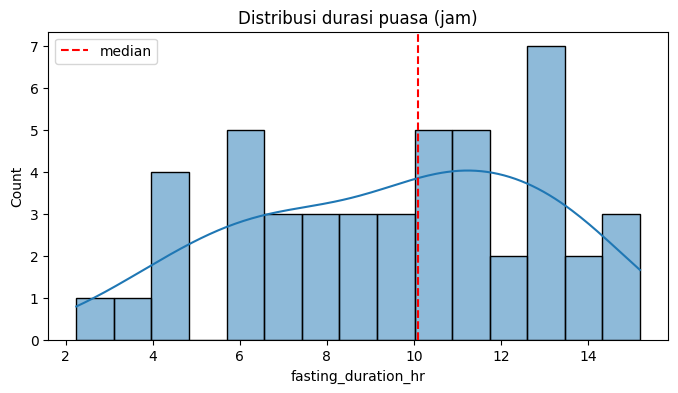

In [20]:
print(fasting_all['fasting_duration_hr'].describe())

plt.figure(figsize=(8,4))
sns.histplot(fasting_all['fasting_duration_hr'], bins=15, kde=True)
plt.axvline(fasting_all['fasting_duration_hr'].median(), color='red', linestyle='--', label='median')
plt.title("Distribusi durasi puasa (jam)")
plt.legend()
plt.show()

Threshold data fasting

In [21]:
def classify_hydration(hr):
    if hr < 10:
        return 'Well Hydrated'
    else:
        return 'At Risk of Dehydration'

fasting_all['hydration_status'] = fasting_all['fasting_duration_hr'].apply(classify_hydration)
fasting_all['hydration_status'].value_counts()

hydration_status
At Risk of Dehydration    24
Well Hydrated             23
Name: count, dtype: int64

kategori nonfasting diklasifikasikan sbg Normal karna dr dataset blg yang nonfasting ini subjek udah minum 1 jam sebelum jadi terhidrasi dong

In [22]:
meta_df_clean['hydration_status'] = np.where(
    meta_df_clean['session_type'] == 'nonfasting', 'Well Hydrated',
    meta_df_clean['fasting_duration_hr'].apply(lambda x: classify_hydration(x) if pd.notna(x) else None)
)
meta_df_clean['hydration_status'].value_counts(dropna=False)

hydration_status
Well Hydrated             100
At Risk of Dehydration     23
Name: count, dtype: int64

In [23]:
meta_df_clean = meta_df_clean.merge(
    result_df[['file', 'duration_min', 'sampling_rate_hz', 'gap_pct']],
    on='file', how='left'
)

class_duration = meta_df_clean.groupby('hydration_status')['duration_min'].sum().sort_values(ascending=False)
print(class_duration)
print("\nProporsi (%):")
print((class_duration / class_duration.sum() * 100).round(1))

hydration_status
Well Hydrated             16678.7
At Risk of Dehydration      452.5
Name: duration_min, dtype: float64

Proporsi (%):
hydration_status
Well Hydrated             97.4
At Risk of Dehydration     2.6
Name: duration_min, dtype: float64


cek ketersediaan 4 kolom sensor final (sesuai hardware: MAX30102, GSR, BME280) di semua file

In [24]:
required_cols = ['PPG_A13_CAL', 'GSR_Skin_Conductance_CAL', 'Temperature_BMP280_CAL', 'Pressure_BMP280_CAL']

def has_required_cols(path):
    with open(path) as f:
        f.readline()
        signal = f.readline().strip().split(',')
        caluncal = f.readline().strip().split(',')
    colnames = [f"{s}_{c}" for s, c in zip(signal, caluncal)]
    return all(c in colnames for c in required_cols)

meta_df_clean['has_required_sensors'] = meta_df_clean['path'].apply(has_required_cols)
meta_df_clean['has_required_sensors'].value_counts()

has_required_sensors
True    123
Name: count, dtype: int64

# **PREPROCESSING**

In [25]:
FS = 51.2  # sampling rate hasil EDA (Hz)

valid_files = meta_df_clean[meta_df_clean['has_required_sensors']].reset_index(drop=True)
print("Total file valid untuk training:", len(valid_files))
valid_files['hydration_status'].value_counts()

Total file valid untuk training: 123


hydration_status
Well Hydrated             100
At Risk of Dehydration     23
Name: count, dtype: int64

In [26]:
from ppg_preprocessing import (
    load_signals,
    prepare_recording,
    extract_preprocessed_features,
    create_windows,
    plot_ppg_comparison,
)

# PPG cleaning preserves raw samples, timestamps, and synchronized sensor rows.
# Process a complete recording before slicing windows to avoid repeated edge effects.


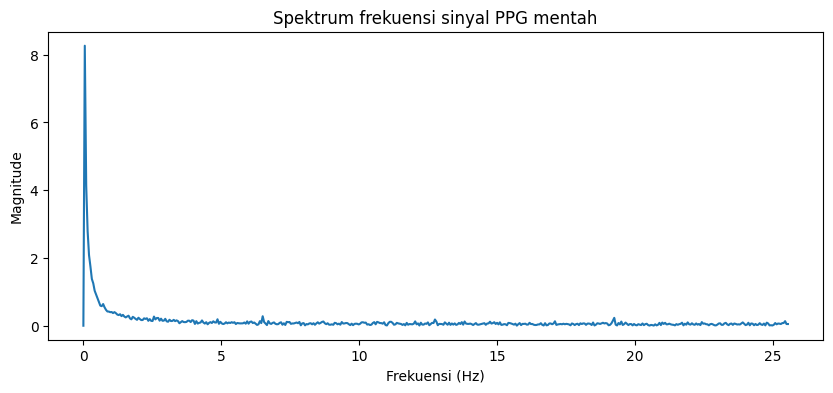

In [27]:
from scipy.fft import fft, fftfreq

sample_raw = load_signals(valid_files.iloc[0]['path'])
sample_ppg = sample_raw['ppg'].iloc[:1000].interpolate(limit_direction='both').to_numpy()
if len(sample_ppg) and np.isfinite(sample_ppg).all():
    n = len(sample_ppg)
    yf = fft(sample_ppg - np.mean(sample_ppg))
    xf = fftfreq(n, 1 / FS)[:n // 2]
    plt.figure(figsize=(10, 4))
    plt.plot(xf, 2.0 / n * np.abs(yf[:n // 2]))
    plt.title("Spektrum frekuensi sinyal PPG mentah")
    plt.xlabel("Frekuensi (Hz)")
    plt.ylabel("Magnitude")
    plt.show()


### **PPG: adaptive gyroscope filtering + smoothing + HeartPy**

Pipeline mengikuti bagian 4.1.5 dari **[3] referensi utama.pdf**: perubahan gyroscope menentukan periode gerakan tinggi/rendah, kemudian adaptive low-pass, smoothing, dan ekstraksi fitur HeartPy. Gerakan mengubah kekuatan filter; tidak menjadi alasan membuang sampel atau window.

Parameter implementasi awal: low-pass Butterworth orde 4, cutoff 4 Hz (gerakan rendah) / 2.5 Hz (gerakan tinggi), jendela gerakan 1 detik, transisi 0.25 detik, dan smoothing 0.15 detik. Parameter ini adalah pilihan implementasi yang dapat disetel, bukan angka yang dinyatakan paper. Penghilangan baseline 0.5 Hz merupakan langkah tambahan yang dapat dikonfigurasi. Prosa paper menyebut low-pass, sedangkan Figure 5 menyebut bandpass; perbedaan ini dicatat agar tidak mengklaim reproduksi parameter yang tidak dilaporkan.

`ppg` menyimpan sinyal mentah dan `ppg_clean` menyimpan hasil filter. Window yang terpengaruh gerakan tetap disimpan. Jika detak tidak dapat diukur dengan andal, fitur yang tidak tersedia tetap NaN dengan `ppg_status` / `ppg_error`; tidak diganti angka fisiologis buatan. HeartPy dapat menolak interval RR yang tidak andal tanpa menghapus sampel PPG. IBI dan RMSSD dalam ms, BPM dalam beats/min, `breathingrate` dalam Hz, dan `breathing_rate_bpm` dalam breaths/min. Flag kualitas, missing sensor, serta gap timestamp ikut disimpan.


Sampel mentah / hasil preprocessing: 388976 / 388976


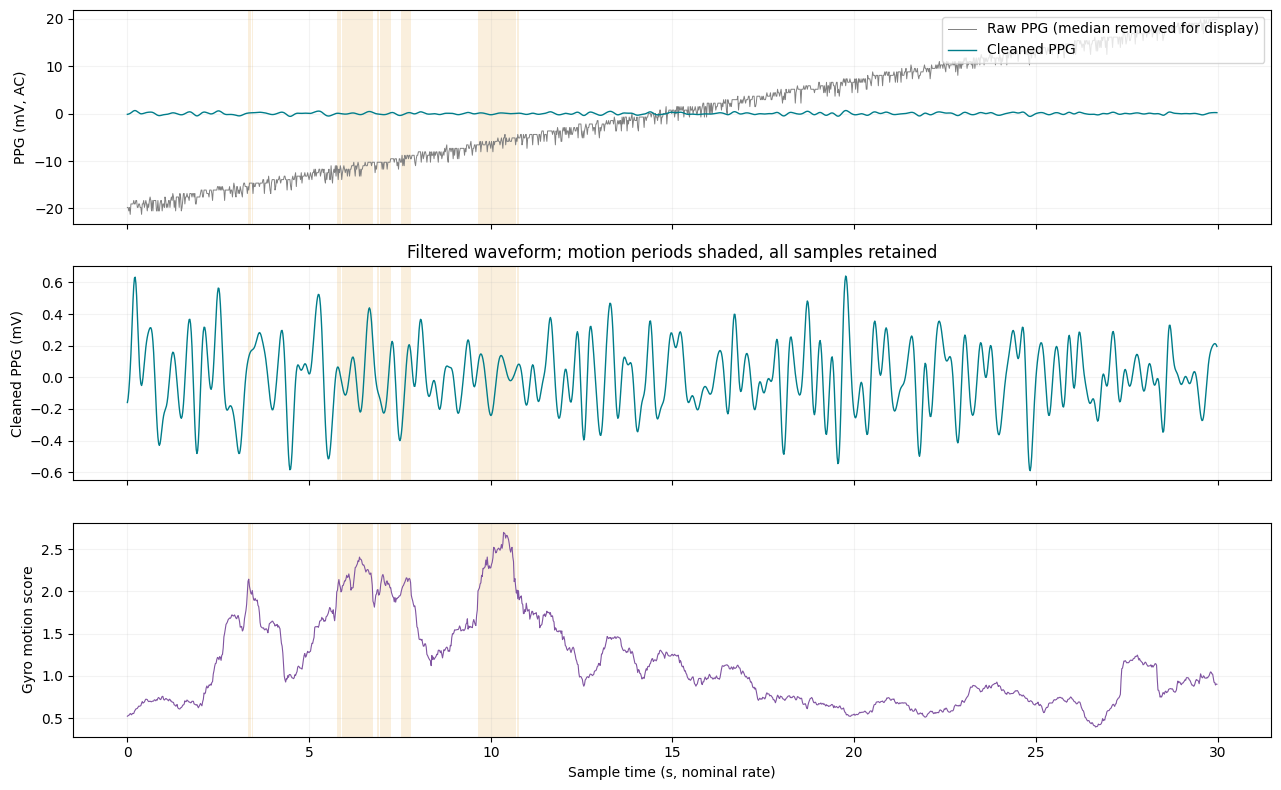

c:\Users\Raisa Shahira\.conda\envs\d2l\lib\site-packages\heartpy\datautils.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


ibi                                    429.988971
bpm                                    139.538463
mean_hr                                139.538463
breathingrate                            0.273898
breathing_rate_bpm                      16.433854
rmssd                                   34.388242
sdnn                                   104.729627
pnn50                                        20.0
n_peaks                                        60
ppg_status                   review_rr_rejections
ppg_error                                        
ppg_rr_rejected_fraction                 0.711864
ppg_feature_valid                            True
ppg_quality_ok                              False
ppg_high_motion_fraction                 0.092448
ppg_interpolated_fraction                     0.0
ppg_missing_fraction                          0.0
ppg_gyro_missing_fraction                     0.0
ppg_timing_gap_count                            0
window_samples                               1536


In [28]:
sample_df = prepare_recording(load_signals(valid_files.iloc[0]['path']), fs=FS)
print(f"Sampel mentah / hasil preprocessing: {len(sample_df)} / {len(sample_df['ppg_clean'])}")
fig = plot_ppg_comparison(sample_df, fs=FS, start_sec=0, duration_sec=30)
plt.show()

preview_windows = create_windows(sample_df, fs=FS, window_sec=30, overlap=0.5)
if preview_windows:
    display(pd.Series(extract_preprocessed_features(preview_windows[0], fs=FS)))


### **GSR**

In [29]:
from scipy.stats import entropy as shannon_entropy

def extract_gsr_features(gsr_segment, fs=51.2, bins=10):
    # Filter sinyalnya dulu sebelum dihitung!
    gsr_clean = lowpass_filter_gsr(gsr_segment, fs=fs)
    
    mean_val = np.mean(gsr_clean)
    var_val = np.var(gsr_clean)
    
    # Hitung entropy dari sinyal yang sudah bersih
    hist, _ = np.histogram(gsr_clean, bins=bins, density=True)
    hist = hist[hist > 0]
    entropy_val = shannon_entropy(hist) if len(hist) > 0 else 0
    
    return {
        'gsr_mean': mean_val, 
        'gsr_var': var_val, 
        'gsr_entropy': entropy_val
    }

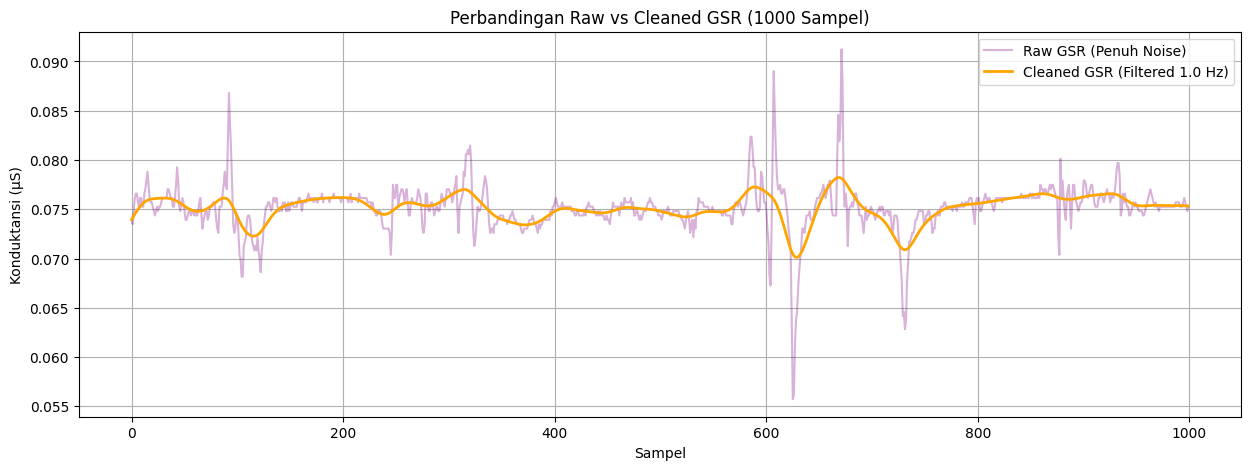

In [30]:
from scipy.signal import butter, filtfilt
import matplotlib.pyplot as plt

# Fungsi Low-Pass Filter
def lowpass_filter_gsr(signal, fs=51.2, cutoff=1.0, order=2):
    nyq = 0.5 * fs
    b, a = butter(order, cutoff / nyq, btype='low')
    if len(signal) <= 3 * max(len(a), len(b)):
        return np.asarray(signal, dtype=float).copy()
    return filtfilt(b, a, signal)

# Ambil data 10.000 sampel
gsr_raw = load_signals(valid_files.iloc[0]['path'])['gsr'].values[3000:4000]  

# filter
gsr_clean = lowpass_filter_gsr(gsr_raw)

#plot
plt.figure(figsize=(15, 5))
plt.plot(gsr_raw, color='purple', alpha=0.3, label='Raw GSR (Penuh Noise)')
plt.plot(gsr_clean, color='orange', linewidth=2, label='Cleaned GSR (Filtered 1.0 Hz)')
plt.title('Perbandingan Raw vs Cleaned GSR (1000 Sampel)')
plt.ylabel('Konduktansi (µS)')
plt.xlabel('Sampel')
plt.legend()
plt.grid(True)
plt.show()

In [31]:
num_files_to_test = 5

for file_idx in range(num_files_to_test):
    print(f"\n=======================================================")
    print(f"               MEMPROSES FILE KE-{file_idx} (GSR)          ")
    print(f"=======================================================")
    
    # 1. Ambil sinyal GSR penuh
    full_signal = load_signals(valid_files.iloc[file_idx]['path'])['gsr'].values
    
    # 2. Setup parameter window (1000 data)
    window_len = 1000
    all_window_results = []
    
    print(f"Total data: {len(full_signal)} sampel...")
    
    # 3. Looping dari awal sampai akhir file per 1000 data
    for start_idx in range(0, len(full_signal), window_len):
        end_idx = start_idx + window_len
        
        # Berhenti kalau sisa data di akhir kurang dari 1000 (window tidak utuh)
        if end_idx > len(full_signal):
            break
            
        # Ambil potongan sinyal
        window_segment = full_signal[start_idx:end_idx]
        
        # Ekstrak fitur menggunakan fungsi filter & ekstraksi buatanmu
        features = extract_gsr_features(window_segment)
        features['window_start'] = start_idx
        
        all_window_results.append(features)

    # 4. Jadikan DataFrame
    df_file_results = pd.DataFrame(all_window_results)
    total_windows = len(df_file_results)
    
    print(f"Total potongan window  : {total_windows}")
    print("--- Nilai Rata-rata Fitur GSR ---")
    
    if total_windows > 0:
        # Menampilkan rata-rata dari fitur gsr_mean, gsr_var, dan gsr_entropy
        print(df_file_results[['gsr_mean', 'gsr_var', 'gsr_entropy']].mean())
    else:
        print("Tidak ada window yang berhasil diekstrak.")


               MEMPROSES FILE KE-0 (GSR)          
Total data: 388976 sampel...
Total potongan window  : 388
--- Nilai Rata-rata Fitur GSR ---
gsr_mean       10.702748
gsr_var         0.377613
gsr_entropy     2.006010
dtype: float64

               MEMPROSES FILE KE-1 (GSR)          
Total data: 16760 sampel...
Total potongan window  : 16
--- Nilai Rata-rata Fitur GSR ---
gsr_mean       0.186055
gsr_var        0.000056
gsr_entropy    1.969220
dtype: float64

               MEMPROSES FILE KE-2 (GSR)          
Total data: 361497 sampel...
Total potongan window  : 361
--- Nilai Rata-rata Fitur GSR ---
gsr_mean       0.255257
gsr_var        0.000034
gsr_entropy    1.857008
dtype: float64

               MEMPROSES FILE KE-3 (GSR)          
Total data: 23959 sampel...
Total potongan window  : 23
--- Nilai Rata-rata Fitur GSR ---
gsr_mean       0.103426
gsr_var        0.000005
gsr_entropy    2.035553
dtype: float64

               MEMPROSES FILE KE-4 (GSR)          
Total data: 10916 sampel.

### **WINDOWING**

In [32]:
def extract_window_features(window_df):
    ppg_feats = extract_preprocessed_features(window_df, fs=FS)

    # Preserve sensor alignment: repair only the GSR copy used by its extractor.
    gsr = pd.Series(window_df['gsr'].to_numpy(dtype=float)).replace([np.inf, -np.inf], np.nan)
    if gsr.notna().any():
        gsr = gsr.interpolate(limit_direction='both').to_numpy()
        gsr_feats = extract_gsr_features(gsr)
    else:
        gsr_feats = {'gsr_mean': np.nan, 'gsr_var': np.nan, 'gsr_entropy': np.nan}
    env_feats = {}
    return {
        **ppg_feats,
        **gsr_feats,
        **env_feats,
        'window_start_sample': int(window_df.index[0]),
        'window_end_sample': int(window_df.index[-1]) + 1,
        'window_samples': len(window_df),
        'window_duration_sec': len(window_df) / FS,
    }

# create_windows retains complete windows plus one uncovered partial tail.
test_windows = create_windows(sample_df, fs=FS, window_sec=30, overlap=0.5)
print("Jumlah window dari satu file (termasuk sisa akhir):", len(test_windows))
if test_windows:
    display(pd.Series(extract_window_features(test_windows[0])))


Jumlah window dari satu file (termasuk sisa akhir): 506


ibi                                    429.988971
bpm                                    139.538463
mean_hr                                139.538463
breathingrate                            0.273898
breathing_rate_bpm                      16.433854
rmssd                                   34.388242
sdnn                                   104.729627
pnn50                                        20.0
n_peaks                                        60
ppg_status                   review_rr_rejections
ppg_error                                        
ppg_rr_rejected_fraction                 0.711864
ppg_feature_valid                            True
ppg_quality_ok                              False
ppg_high_motion_fraction                 0.092448
ppg_interpolated_fraction                     0.0
ppg_missing_fraction                          0.0
ppg_gyro_missing_fraction                     0.0
ppg_timing_gap_count                            0
window_samples                               1536


In [33]:
import time

all_windows_data = []
start_time = time.time()

for index, row in valid_files.iterrows():
    # Clean each full recording once, then extract all windows including the tail.
    df_signal = prepare_recording(load_signals(row['path']), fs=FS)
    windows = create_windows(df_signal, fs=FS, window_sec=30, overlap=0.5)
    for w_idx, w_df in enumerate(windows):
        feats = extract_window_features(w_df)
        feats.update({
            'fasting_duration_hr': row['fasting_duration_hr'],
            'hydration_status': row['hydration_status'],
            'session_type': row['session_type'],
            'subject_id': row['subject_id'],
            'file': row['file'],
            'window_id': w_idx,
        })
        all_windows_data.append(feats)
    if (index + 1) % 10 == 0 or index + 1 == len(valid_files):
        print(f"Memproses file {index + 1}/{len(valid_files)}...")

feature_df = pd.DataFrame(all_windows_data)
output_csv = "dataset_final_features_reprocessed.csv"
feature_df.to_csv(output_csv, index=False)
print(f"Ekstraksi selesai dalam {(time.time() - start_time) / 60:.2f} menit")
print(f"Tersimpan: {output_csv} | {len(feature_df)} window")
print("Semua window disimpan; status kualitas tidak dipakai untuk menghapus baris.")
if not feature_df.empty:
    display(feature_df['ppg_status'].value_counts(dropna=False).rename('windows'))
    print("Fitur HeartPy tersedia:", int(feature_df['ppg_feature_valid'].sum()))
    print("Window dengan gerakan tinggi:", int(feature_df['ppg_high_motion_fraction'].gt(0).sum()))


Memproses file 10/123...
Memproses file 20/123...
Memproses file 30/123...
Memproses file 40/123...
Memproses file 50/123...
Memproses file 60/123...
Memproses file 70/123...
Memproses file 80/123...
Memproses file 90/123...
Memproses file 100/123...
Memproses file 110/123...
Memproses file 120/123...
Memproses file 123/123...
Ekstraksi selesai dalam 8.34 menit
Tersimpan: dataset_final_features_reprocessed.csv | 12944 window
Semua window disimpan; status kualitas tidak dipakai untuk menghapus baris.


ppg_status
review_rr_rejections        7927
ok                          1747
heartpy_failed              1433
timing_gap                  1046
insufficient_valid_beats     761
review_bpm_range              19
missing_ppg                   11
Name: windows, dtype: int64

Fitur HeartPy tersedia: 9674
Window dengan gerakan tinggi: 10506


In [34]:
# Load dataset final yang baru saja kita simpan
df = pd.read_csv("dataset_final_features_reprocessed.csv")

print(f"Total baris data loaded: {len(df)}")
print("Jumlah kolom:", len(df.columns))
print("\nContoh 3 baris teratas:")
display(df.head(3))

# Cek distribusi target regresi kita (fasting_duration_hr)
print("\nStatistik Target (Jam Sejak Minum):")
print(df['fasting_duration_hr'].describe())

Total baris data loaded: 12944
Jumlah kolom: 33

Contoh 3 baris teratas:


,ibi,bpm,mean_hr,breathingrate,breathing_rate_bpm,rmssd,sdnn,pnn50,n_peaks,ppg_status,...,gsr_var,gsr_entropy,window_start_sample,window_end_sample,fasting_duration_hr,hydration_status,session_type,subject_id,file,window_id
0,429.988971,139.538463,139.538463,0.273898,16.433854,34.388242,104.729627,20.0,60,review_rr_rejections,...,2.241450e-07,1.719518,0,1536,6.174444,Well Hydrated,fasting,S1,20210408100028Apr8_10_00_fasting.csv,0
1,431.122917,139.171447,139.171447,0.154799,9.287926,30.443451,117.951409,0.0,64,review_rr_rejections,...,3.884952e-07,1.559357,768,2304,6.174444,Well Hydrated,fasting,S1,20210408100028Apr8_10_00_fasting.csv,1
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22,insufficient_valid_beats,...,3.449900e-06,1.430142,1536,3072,6.174444,Well Hydrated,fasting,S1,20210408100028Apr8_10_00_fasting.csv,2



Statistik Target (Jam Sejak Minum):
count    4307.000000
mean        8.902295
std         3.117636
min         2.245278
25%         6.174444
50%         9.121111
75%        11.492778
max        15.197500
Name: fasting_duration_hr, dtype: float64


At Risk of Dehydration paling sedikit dan berasal dari sesi fasting yang durasinya >= 10 jam

## **SPLIT N TRAIN**

REVISION (bismilla)

In [35]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [36]:
from sklearn.base import clone
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

FEATURE_COLS = ['gsr_mean', 'gsr_var', 'gsr_entropy', 'mean_hr', 'rmssd', 'sdnn', 'pnn50', 'n_peaks', 'ppg_available']
GSR_COLS = ['gsr_mean', 'gsr_var', 'gsr_entropy']
PPG_COLS = ['mean_hr', 'rmssd', 'sdnn', 'pnn50', 'n_peaks']


def prepare_regression_cv_data(df):
    """Rebuild the measured fasting regression sample and episode groups."""
    df_clean = df.loc[
        df['session_type'].eq('fasting') & df['fasting_duration_hr'].notna()
    ].copy().reset_index(drop=True)
    record_start = pd.to_datetime(
        df_clean['file'].str.extract(r'^(\d{14})')[0], format='%Y%m%d%H%M%S'
    )
    fasting_start = record_start - pd.to_timedelta(df_clean['fasting_duration_hr'], unit='h')
    df_clean['episode_id'] = (
        df_clean['subject_id'].astype(str) + '_'
        + fasting_start.dt.round('min').dt.strftime('%Y%m%d%H%M%S')
    )
    if df_clean['episode_id'].isna().any():
        raise ValueError('Ada file tanpa timestamp valid untuk episode_id.')

    episode_count = df_clean.groupby('subject_id')['episode_id'].nunique()
    eligible_subjects = episode_count[episode_count >= 2].index
    df_clean = df_clean.loc[df_clean['subject_id'].isin(eligible_subjects)].copy().reset_index(drop=True)
    if df_clean['episode_id'].nunique() < 5:
        raise ValueError('GroupKFold 5-fold membutuhkan sedikitnya lima episode.')
    for col in GSR_COLS + PPG_COLS:
        df_clean[col] = df_clean[col].astype(float)

    # Definisi ppg_available dipertahankan dari notebook awal.
    df_clean['ppg_available'] = (
        df_clean[PPG_COLS].notna().all(axis=1)
        & df_clean[PPG_COLS].ne(-1).all(axis=1)
        & df_clean['ppg_feature_valid'].eq(True)
    ).astype('int8')
    X = df_clean[FEATURE_COLS].copy()
    y = df_clean['fasting_duration_hr'].copy()
    groups = df_clean['episode_id'].copy()
    episode_id = df_clean['episode_id'].copy()
    return df_clean, X, y, groups, episode_id


def select_covered_episode_folds(X, y, groups, subject_id, n_splits=5):
    """Stratify by subject, group by episode, retry until all test subjects have train history."""
    for seed in range(42, 1042):
        gkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed)
        folds = list(gkf.split(X, subject_id, groups))
        if all(
            set(subject_id.iloc[test_idx]).issubset(set(subject_id.iloc[train_idx]))
            and set(groups.iloc[test_idx]).isdisjoint(set(groups.iloc[train_idx]))
            for train_idx, test_idx in folds
        ):
            return gkf, folds, seed
    raise ValueError('Tidak ditemukan split episode dengan semua subjek test terwakili di train.')


def personal_zscore_from_train(X_train, X_test, train_subjects, test_subjects):
    """Use train-only per-subject statistics; invalid/missing PPG becomes zero."""
    X_train, X_test = X_train.copy(), X_test.copy()
    train_ppg_valid = X_train['ppg_available'].eq(1)
    test_ppg_valid = X_test['ppg_available'].eq(1)
    for col in GSR_COLS + PPG_COLS:
        valid_train = train_ppg_valid if col in PPG_COLS else pd.Series(True, index=X_train.index)
        stats = pd.DataFrame({
            'subject_id': train_subjects.loc[valid_train].to_numpy(),
            'value': X_train.loc[valid_train, col].to_numpy(),
        }).groupby('subject_id')['value'].agg(['mean', 'std'])
        means = stats['mean']
        stds = stats['std'].replace(0, 1).fillna(1)
        X_train[col] = (
            (X_train[col] - train_subjects.map(means)) / train_subjects.map(stds)
        ).fillna(0.0)
        X_test[col] = (
            (X_test[col] - test_subjects.map(means)) / test_subjects.map(stds)
        ).fillna(0.0)
        if col in PPG_COLS:
            X_train.loc[~train_ppg_valid, col] = 0.0
            X_test.loc[~test_ppg_valid, col] = 0.0
    return X_train, X_test


def evaluate_episode_cv(regressor, df_clean, X, y, folds):
    oof_rows = []
    for fold, (train_idx, test_idx) in enumerate(folds, 1):
        train_subjects = df_clean.iloc[train_idx]['subject_id']
        test_subjects = df_clean.iloc[test_idx]['subject_id']
        if not set(test_subjects).issubset(set(train_subjects)):
            raise ValueError(f'Fold {fold}: subjek test tanpa kalibrasi train.')
        X_train, X_test = personal_zscore_from_train(
            X.iloc[train_idx], X.iloc[test_idx], train_subjects, test_subjects
        )
        if X_train.isna().any().any() or X_test.isna().any().any():
            raise ValueError(f'Fold {fold}: fitur NaN setelah normalisasi.')
        model = clone(regressor)
        model.fit(X_train, y.iloc[train_idx])
        y_pred = model.predict(X_test)
        oof_rows.append(pd.DataFrame({
            'subject_id': test_subjects.to_numpy(),
            'episode_id': df_clean.iloc[test_idx]['episode_id'].to_numpy(),
            'file': df_clean.iloc[test_idx]['file'].to_numpy(),
            'ppg_available': X_test['ppg_available'].to_numpy(),
            'y_true': y.iloc[test_idx].to_numpy(),
            'y_pred': y_pred,
        }))
        print(f'Fold {fold}: MAE window = {mean_absolute_error(y.iloc[test_idx], y_pred):.4f} jam')
    oof_predictions = pd.concat(oof_rows, ignore_index=True)
    if len(oof_predictions) != len(df_clean):
        raise ValueError('Jumlah prediksi OOF tidak sama dengan jumlah window evaluasi.')
    oof_by_file = oof_predictions.groupby(
        ['subject_id', 'episode_id', 'file'], as_index=False
    ).agg(
        y_true=('y_true', 'first'),
        y_pred=('y_pred', 'mean'),
        ppg_available=('ppg_available', 'mean'),
    )
    return oof_predictions, oof_by_file


def oof_metrics(oof_by_file):
    return pd.Series({
        'MAE (jam)': mean_absolute_error(oof_by_file['y_true'], oof_by_file['y_pred']),
        'RMSE (jam)': np.sqrt(mean_squared_error(oof_by_file['y_true'], oof_by_file['y_pred'])),
        'R2': r2_score(oof_by_file['y_true'], oof_by_file['y_pred']),
    })


def oof_comparison_column(oof_by_file):
    results = oof_metrics(oof_by_file).to_dict()
    for state, label in ((True, 'PPG valid MAE (jam)'), (False, 'PPG diimputasi MAE (jam)')):
        subset = oof_by_file.loc[oof_by_file['ppg_available'].ge(0.5).eq(state)]
        results[label] = (
            mean_absolute_error(subset['y_true'], subset['y_pred']) if len(subset) else np.nan
        )
    for subject, subset in oof_by_file.groupby('subject_id'):
        results[f'MAE {subject} (jam)'] = mean_absolute_error(subset['y_true'], subset['y_pred'])
    return pd.Series(results)


In [37]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor

# Blok RF selalu memuat ulang CSV dan membangun seluruh variabel evaluasi.
df = pd.read_csv('dataset_final_features_reprocessed.csv')
df_clean, X, y, groups, episode_id = prepare_regression_cv_data(df)
gkf, folds, cv_seed = select_covered_episode_folds(X, y, groups, df_clean['subject_id'])
rf_model = RandomForestRegressor(
    n_estimators=35, max_depth=8, min_samples_leaf=4, random_state=42, n_jobs=-1
)
print(f'RF TinyML: {len(df_clean)} window, {groups.nunique()} episode, seed split {cv_seed}')
oof_predictions, oof_by_file = evaluate_episode_cv(rf_model, df_clean, X, y, folds)
print(f'\nRF TinyML: {len(oof_by_file)} rekaman OOF')
display(oof_metrics(oof_by_file).to_frame('Random Forest TinyML'))


RF TinyML: 3983 window, 29 episode, seed split 43
Fold 1: MAE window = 2.7651 jam
Fold 2: MAE window = 2.6428 jam
Fold 3: MAE window = 2.9801 jam
Fold 4: MAE window = 2.6860 jam
Fold 5: MAE window = 3.4087 jam

RF TinyML: 41 rekaman OOF


,Random Forest TinyML
MAE (jam),3.225877
RMSE (jam),3.954687
R2,-0.523331


###EVALUASI Random Forest

In [38]:
# Diagnostic RF dari prediksi OOF GroupKFold; tidak melatih model ulang.
rf_by_subject = oof_by_file.assign(
    abs_error=lambda frame: (frame['y_true'] - frame['y_pred']).abs()
).groupby('subject_id').agg(
    n_file=('file', 'size'),
    mae_jam=('abs_error', 'mean'),
)
display(rf_by_subject)


,n_file,mae_jam
subject_id,,
S1,23,3.865035
S2,4,3.294679
S4,8,2.588331
S5,4,0.820073
S6,2,3.099754


CONVERT MODEL

In [39]:
!pip install emlearn

In [40]:
import emlearn
from sklearn.ensemble import RandomForestRegressor

# Model akhir dilatih pada seluruh data terukur; ini bukan evaluasi OOF.
df = pd.read_csv('dataset_final_features_reprocessed.csv')
df_clean, X, y, groups, episode_id = prepare_regression_cv_data(df)
X_full, _ = personal_zscore_from_train(
    X, X, df_clean['subject_id'], df_clean['subject_id']
)
rf_tinyml = RandomForestRegressor(
    n_estimators=35, max_depth=8, min_samples_leaf=4, random_state=42
)
rf_tinyml.fit(X_full, y)
c_model = emlearn.convert(rf_tinyml, dtype='float32')
nama_file = 'rf_hydration_model.h'
c_model.save(file=nama_file, name='hydration_rf')
print(f'Model RF TinyML global diekspor ke {nama_file}')


Model RF TinyML global diekspor ke rf_hydration_model.h


In [41]:
import pandas as pd
import numpy as np
import emlearn
from sklearn.ensemble import RandomForestRegressor

# Muat ulang CSV; model akhir S1 memakai normalisasi personal yang sama dengan CV.
df = pd.read_csv('dataset_final_features_reprocessed.csv')
df_clean, X, y, groups, episode_id = prepare_regression_cv_data(df)
target_user = 'S1'
user_mask = df_clean['subject_id'].eq(target_user)
X_user = X.loc[user_mask].copy()
y_user = y.loc[user_mask].copy()
user_subjects = df_clean.loc[user_mask, 'subject_id']
X_user, _ = personal_zscore_from_train(X_user, X_user, user_subjects, user_subjects)
rf_tinyml = RandomForestRegressor(
    n_estimators=35, max_depth=8, min_samples_leaf=4, random_state=42
)
rf_tinyml.fit(X_user, y_user)
c_model = emlearn.convert(rf_tinyml, dtype='float32')
nama_file = f'rf_hydration_model_{target_user}.h'
c_model.save(file=nama_file, name='hydration_rf')
print(f'Model RF TinyML khusus {target_user} diekspor ke {nama_file}')


Model RF TinyML khusus S1 diekspor ke rf_hydration_model_S1.h


---
## **EKSPERIMEN MODEL EXTRATREES (Sabry et al., 2022)**
Mengacu pada referensi utama *Sabry et al. (2022)* (halaman 12-14, Tabel 3 & 4), algoritma **Extra Trees (Extremely Randomized Trees)** terbukti mencapai error prediksi terkecil (*lowest MAE & RMSE*) dibandingkan Random Forest dan model regresi lainnya pada data fisiologis multisensor. 

Di bawah ini diimplementasikan pengujian ExtraTrees dengan validasi silang (5-Fold CV), perbandingan *head-to-head*, dan ekspor model TinyML ke format C Header (`et_hydration_model_S1.h`).

In [42]:
import pandas as pd
import numpy as np
from sklearn.ensemble import ExtraTreesRegressor

# Blok ET selalu memuat ulang CSV dan membangun seluruh variabel evaluasi.
df = pd.read_csv('dataset_final_features_reprocessed.csv')
df_clean, X, y, groups, episode_id = prepare_regression_cv_data(df)
gkf, folds, cv_seed = select_covered_episode_folds(X, y, groups, df_clean['subject_id'])
et_model = ExtraTreesRegressor(
    n_estimators=35, max_depth=8, min_samples_leaf=4, random_state=42, n_jobs=-1
)
print(f'ET TinyML: {len(df_clean)} window, {groups.nunique()} episode, seed split {cv_seed}')
oof_predictions_et, oof_by_file_et = evaluate_episode_cv(et_model, df_clean, X, y, folds)
print(f'\nET TinyML: {len(oof_by_file_et)} rekaman OOF')
display(oof_metrics(oof_by_file_et).to_frame('Extra Trees TinyML'))


ET TinyML: 3983 window, 29 episode, seed split 43
Fold 1: MAE window = 2.6740 jam
Fold 2: MAE window = 2.6175 jam
Fold 3: MAE window = 2.1282 jam
Fold 4: MAE window = 2.7838 jam
Fold 5: MAE window = 3.3363 jam

ET TinyML: 41 rekaman OOF


,Extra Trees TinyML
MAE (jam),2.943292
RMSE (jam),3.553564
R2,-0.229981


In [43]:
# Seluruh angka dihitung ulang dari prediksi OOF level rekaman.
comparison_df = pd.DataFrame({
    'Random Forest TinyML': oof_comparison_column(oof_by_file),
    'Extra Trees TinyML': oof_comparison_column(oof_by_file_et),
}).round(3)
display(comparison_df)


,Random Forest TinyML,Extra Trees TinyML
MAE (jam),3.226,2.943
RMSE (jam),3.955,3.554
R2,-0.523,-0.230
PPG valid MAE (jam),3.018,2.768
PPG diimputasi MAE (jam),4.235,3.794
MAE S1 (jam),3.865,3.368
MAE S2 (jam),3.295,3.144
MAE S4 (jam),2.588,2.127
MAE S5 (jam),0.820,1.600
MAE S6 (jam),3.100,3.607


In [44]:
import emlearn
from sklearn.ensemble import ExtraTreesRegressor

# Muat ulang data agar ekspor ET tidak bergantung pada blok evaluasi RF/ET.
df = pd.read_csv('dataset_final_features_reprocessed.csv')
df_clean, X, y, groups, episode_id = prepare_regression_cv_data(df)
target_user = 'S1'
user_mask = df_clean['subject_id'].eq(target_user)
X_user = X.loc[user_mask].copy()
y_user = y.loc[user_mask].copy()
user_subjects = df_clean.loc[user_mask, 'subject_id']
X_user, _ = personal_zscore_from_train(X_user, X_user, user_subjects, user_subjects)
et_tinyml = ExtraTreesRegressor(
    n_estimators=35, max_depth=8, min_samples_leaf=4, random_state=42
)
et_tinyml.fit(X_user, y_user)
c_model_et = emlearn.convert(et_tinyml, dtype='float32')
nama_file_et = f'et_hydration_model_{target_user}.h'
c_model_et.save(file=nama_file_et, name='hydration_et')
print(f'Model ET TinyML khusus {target_user} diekspor ke {nama_file_et}')


Model ET TinyML khusus S1 diekspor ke et_hydration_model_S1.h


---
## **BASELINE MODEL: LINEAR REGRESSION (Sabry et al., 2022)**
Sebagaimana dilakukan pada studi referensi utama *Sabry et al. (2022)* (Bagian 4.2), algoritma **Linear Regression** digunakan sebagai model pembanding dasar (*baseline benchmark*). 

Linear Regression mengasumsikan hubungan linier sederhana antara perubahan sinyal sensor (GSR, HR, HRV) dengan durasi puasa / tingkat dehidrasi. Evaluasi ini membuktikan secara empiris mengapa model *tree-based ensemble* (Random Forest & Extra Trees) jauh lebih unggul dalam memodelkan interaksi fisiologis yang non-linear.

In [45]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

# Blok LR selalu memuat ulang CSV; tidak memakai variabel sisa dari Extra Trees.
df = pd.read_csv('dataset_final_features_reprocessed.csv')
df_clean, X, y, groups, episode_id = prepare_regression_cv_data(df)
gkf, folds, cv_seed = select_covered_episode_folds(X, y, groups, df_clean['subject_id'])
lr_model = LinearRegression()
print(f'LR: {len(df_clean)} window, {groups.nunique()} episode, seed split {cv_seed}')
oof_predictions_lr, oof_by_file_lr = evaluate_episode_cv(lr_model, df_clean, X, y, folds)
print(f'\nLR: {len(oof_by_file_lr)} rekaman OOF')
display(oof_metrics(oof_by_file_lr).to_frame('Linear Regression'))


LR: 3983 window, 29 episode, seed split 43
Fold 1: MAE window = 3.0072 jam
Fold 2: MAE window = 2.4110 jam
Fold 3: MAE window = 2.0416 jam
Fold 4: MAE window = 2.3633 jam
Fold 5: MAE window = 7.6519 jam

LR: 41 rekaman OOF


,Linear Regression
MAE (jam),3.569890
RMSE (jam),5.155185
R2,-1.588562


In [46]:
# Metrik resmi RF/ET memakai hyperparameter TinyML yang akan di-deploy.
comparison_3models = pd.DataFrame({
    'Linear Regression': oof_comparison_column(oof_by_file_lr),
    'Random Forest TinyML': oof_comparison_column(oof_by_file),
    'Extra Trees TinyML': oof_comparison_column(oof_by_file_et),
}).round(3)
display(comparison_3models)


,Linear Regression,Random Forest TinyML,Extra Trees TinyML
MAE (jam),3.570,3.226,2.943
RMSE (jam),5.155,3.955,3.554
R2,-1.589,-0.523,-0.230
PPG valid MAE (jam),3.388,3.018,2.768
PPG diimputasi MAE (jam),4.454,4.235,3.794
MAE S1 (jam),3.487,3.865,3.368
MAE S2 (jam),3.272,3.295,3.144
MAE S4 (jam),3.572,2.588,2.127
MAE S5 (jam),3.050,0.820,1.600
MAE S6 (jam),6.152,3.100,3.607


### Diagnostic prediksi OOF per rekaman
Bandingkan titik dengan garis prediksi sempurna dan rata-rata target. R2 negatif berarti galat kuadrat lebih besar daripada prediksi konstan rata-rata target.


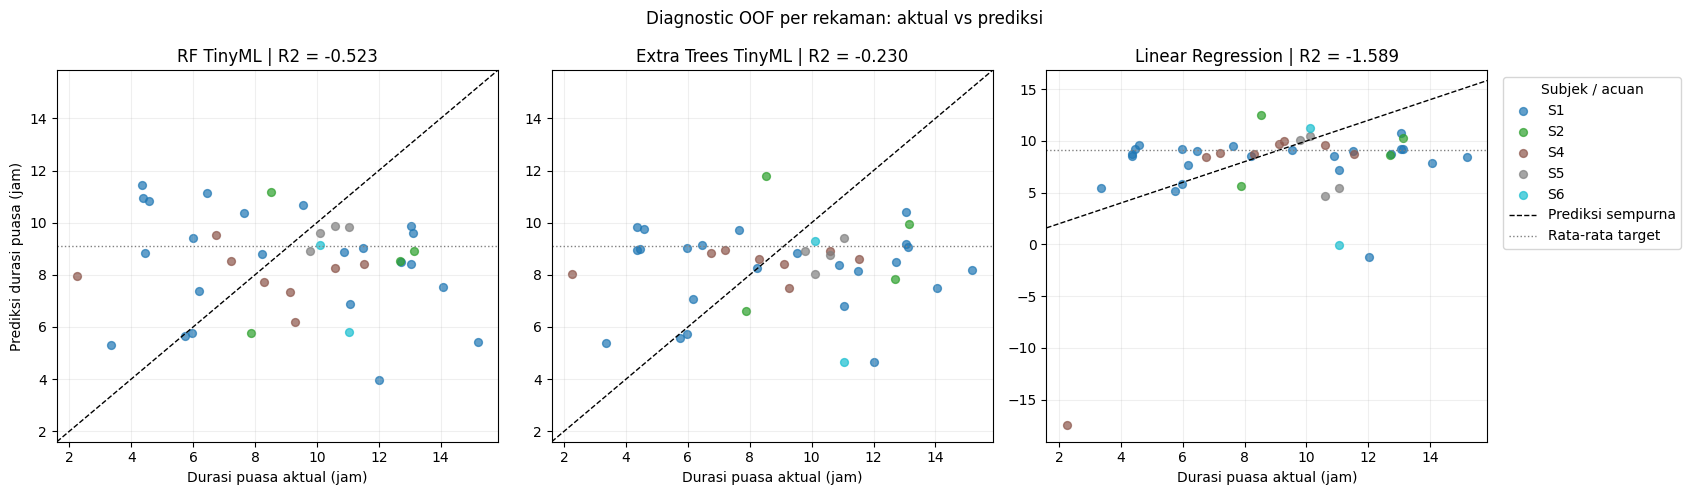

In [47]:
import matplotlib.pyplot as plt

# Satu titik = satu rekaman OOF; garis diagonal menunjukkan prediksi sempurna.
model_oof = {
    'RF TinyML': oof_by_file,
    'Extra Trees TinyML': oof_by_file_et,
    'Linear Regression': oof_by_file_lr,
}
true_values = np.concatenate([frame['y_true'].to_numpy() for frame in model_oof.values()])
true_lo, true_hi = float(np.min(true_values)), float(np.max(true_values))
x_margin = max((true_hi - true_lo) * 0.05, 0.5)
subjects = sorted(set().union(*(frame['subject_id'].unique() for frame in model_oof.values())))
colors = dict(zip(subjects, plt.cm.tab10(np.linspace(0, 1, len(subjects)))))
fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharex=True)
for ax, (name, frame) in zip(axes, model_oof.items()):
    for subject, subset in frame.groupby('subject_id'):
        ax.scatter(subset['y_true'], subset['y_pred'], s=32, alpha=0.7,
                   color=colors[subject], label=subject)
    pred_lo, pred_hi = float(frame['y_pred'].min()), float(frame['y_pred'].max())
    y_lo, y_hi = min(true_lo, pred_lo), max(true_hi, pred_hi)
    y_margin = max((y_hi - y_lo) * 0.05, 0.5)
    ax.plot([true_lo - x_margin, true_hi + x_margin],
            [true_lo - x_margin, true_hi + x_margin],
            '--', color='black', linewidth=1, label='Prediksi sempurna')
    ax.axhline(frame['y_true'].mean(), color='gray', linestyle=':', linewidth=1,
               label='Rata-rata target')
    ax.set_title(f"{name} | R2 = {r2_score(frame['y_true'], frame['y_pred']):.3f}")
    ax.set_xlabel('Durasi puasa aktual (jam)')
    ax.grid(alpha=0.2)
    ax.set_ylim(y_lo - y_margin, y_hi + y_margin)
axes[0].set_ylabel('Prediksi durasi puasa (jam)')
axes[-1].legend(title='Subjek / acuan', bbox_to_anchor=(1.02, 1), loc='upper left')
for ax in axes:
    ax.set_xlim(true_lo - x_margin, true_hi + x_margin)
fig.suptitle('Diagnostic OOF per rekaman: aktual vs prediksi')
fig.tight_layout()
plt.show()
